# Baseline vs HDE Comparison
## Hypothesis-Driven Evolution for Circle Packing

Key experiment versions (10 runs each, `gpt-5.4-mini`, 100 iterations):
- **v0**: Baseline (original prompt, 90s timeout)
- **v0.2**: Baseline + 300s timeout
- **v1**: HDE (hypothesis prompt + knowledge base, 90s timeout)
- **v1.3**: HDE + all fixes + prompt cleanup + 300s timeout
- **v1.4**: HDE + per-island knowledge + confidence filtering + softer prompt + 300s timeout

In [11]:
import json
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from scipy import stats
from itertools import combinations

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

TARGET = 2.635

# v1.4 runs are in the worktree output directory
V14_DIR = Path('/srv/eeg_reconstruction/reese/external_repos/openevolve-v14/examples/circle_packing/hde_v14_runs')

EXPERIMENTS = {
    'v0: Baseline':        {'dir': Path('baseline_runs'),             'color': '#1f77b4', 'n_runs': 10},
    'v0.2: +T300':         {'dir': Path('baseline_v02_runs'),         'color': '#17becf', 'n_runs': 10},
    'v1: HDE':             {'dir': Path('hde_v1_runs'),               'color': '#d62728', 'n_runs': 10},
    'v1.3: HDE+Clean':     {'dir': Path('hde_v13_runs'),              'color': '#ff7f0e', 'n_runs': 10},
    'v1.4: HDE+Island':    {'dir': V14_DIR,                           'color': '#8c564b', 'n_runs': 10},
}

In [ ]:
def parse_log(log_path):
    """Parse an OpenEvolve log file and extract per-iteration data."""
    iterations = []
    best_events = []
    errors = []
    pending_tokens = None  # Token usage appears before the iteration completion line
    
    with open(log_path) as f:
        for line in f:
            # Parse token usage (appears before iteration completion)
            token_match = re.search(
                r'Token usage: prompt=(\d+), completion=(\d+), total=(\d+)', line
            )
            if token_match:
                pending_tokens = {
                    'prompt_tokens': int(token_match.group(1)),
                    'completion_tokens': int(token_match.group(2)),
                    'total_tokens': int(token_match.group(3)),
                }
            
            # Parse completed iterations with metrics
            iter_match = re.search(
                r'Iteration (\d+):.*completed in ([\d.]+)s', line
            )
            if iter_match:
                it = int(iter_match.group(1))
                duration = float(iter_match.group(2))
                entry = {'iteration': it, 'duration': duration}
                if pending_tokens:
                    entry.update(pending_tokens)
                    pending_tokens = None
                iterations.append(entry)
            
            # Parse evaluation results
            if 'Evaluated program' in line:
                score_match = re.search(r'combined_score=([\d.]+)', line)
                sr_match = re.search(r'sum_radii=([\d.]+)', line)
                val_match = re.search(r'validity=([\d.]+)', line)
                et_match = re.search(r'eval_time=([\d.]+)', line)
                
                if iterations and score_match:
                    iterations[-1].update({
                        'combined_score': float(score_match.group(1)),
                        'sum_radii': float(sr_match.group(1)) if sr_match else 0,
                        'validity': float(val_match.group(1)) if val_match else 0,
                        'eval_time': float(et_match.group(1)) if et_match else 0,
                    })
            
            # Parse best program events
            star_match = re.search(r'New best solution found at iteration (\d+)', line)
            if star_match:
                best_events.append(int(star_match.group(1)))
            
            # Parse errors
            if 'error=' in line and ('Iteration' in line or 'Metrics' in line):
                err_match = re.search(r'error=(.+?)(?:,|$)', line)
                if err_match:
                    errors.append(err_match.group(1).strip())
    
    return {'iterations': iterations, 'best_events': best_events, 'errors': errors}


def load_experiment(base_dir, n_runs):
    """Load all runs for an experiment."""
    runs = {}
    for i in range(1, n_runs + 1):
        log_files = sorted(glob.glob(str(base_dir / f'run_{i}' / 'logs' / '*.log')))
        if log_files:
            data = parse_log(log_files[-1])
            if len(data['iterations']) >= 10:
                runs[i] = data
    return runs

In [13]:
# Load all experiments
all_data = {}
for name, cfg in EXPERIMENTS.items():
    runs = load_experiment(cfg['dir'], cfg['n_runs'])
    all_data[name] = runs
    n_complete = sum(1 for r in runs.values() if len(r['iterations']) >= 95)
    print(f"{name}: {len(runs)} runs loaded ({n_complete} completed 95+ iters)")

v0: Baseline: 10 runs loaded (9 completed 95+ iters)
v0.2: +T300: 10 runs loaded (9 completed 95+ iters)
v1: HDE: 10 runs loaded (9 completed 95+ iters)
v1.3: HDE+Clean: 10 runs loaded (10 completed 95+ iters)
v1.4: HDE+Island: 10 runs loaded (0 completed 95+ iters)


## 1. Convergence Curves (Best Score Over Time)

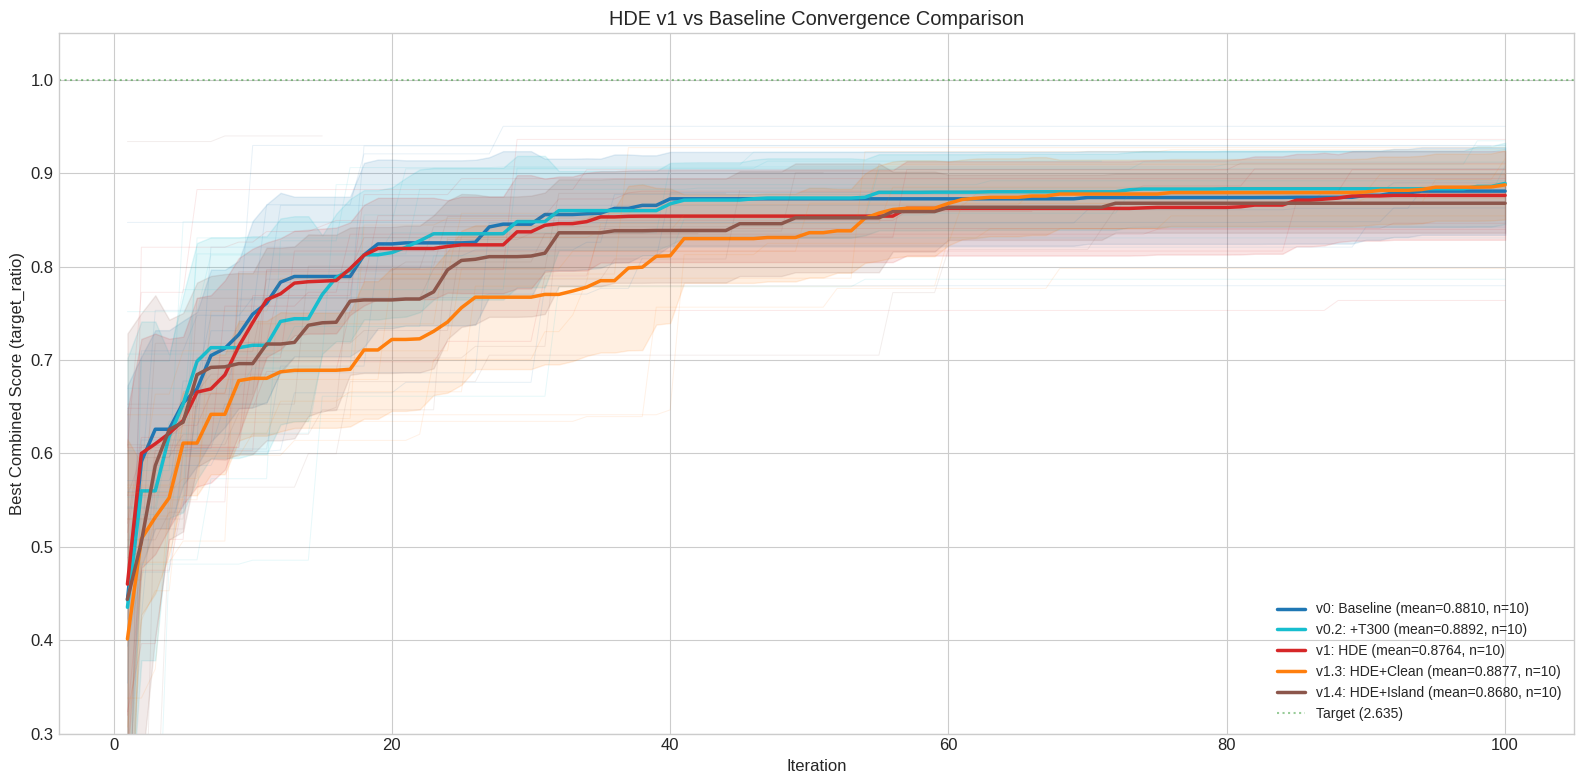

In [14]:
def get_best_trajectory(data):
    """Build cumulative best score trajectory."""
    sorted_iters = sorted(data['iterations'], key=lambda x: x['iteration'])
    best_so_far = 0.0
    trajectory = []
    for it_data in sorted_iters:
        score = it_data.get('combined_score', 0.0)
        best_so_far = max(best_so_far, score)
        trajectory.append((it_data['iteration'], best_so_far))
    return trajectory


def interpolate_trajectories(runs, max_iter=100):
    """Interpolate all run trajectories to common iteration axis."""
    common_iters = np.arange(1, max_iter + 1)
    interpolated = []
    for data in runs.values():
        traj = get_best_trajectory(data)
        if not traj:
            continue
        iters, vals = zip(*traj)
        iters, vals = list(iters), list(vals)
        interp = []
        val_idx = 0
        for ci in common_iters:
            while val_idx < len(iters) - 1 and iters[val_idx + 1] <= ci:
                val_idx += 1
            interp.append(vals[min(val_idx, len(vals) - 1)])
        interpolated.append(interp)
    return common_iters, np.array(interpolated)


fig, ax = plt.subplots(figsize=(16, 8))

for name, cfg in EXPERIMENTS.items():
    runs = all_data[name]
    color = cfg['color']
    
    # Plot individual runs faintly
    for run_id, data in runs.items():
        traj = get_best_trajectory(data)
        if traj:
            iters, vals = zip(*traj)
            ax.plot(iters, vals, color=color, alpha=0.1, linewidth=0.7)
    
    # Plot mean +/- std
    common_iters, matrix = interpolate_trajectories(runs)
    if len(matrix) > 0:
        mean_vals = np.mean(matrix, axis=0)
        std_vals = np.std(matrix, axis=0)
        ax.plot(common_iters, mean_vals, color=color, linewidth=2.5,
                label=f'{name} (mean={mean_vals[-1]:.4f}, n={len(matrix)})')
        ax.fill_between(common_iters, mean_vals - std_vals, mean_vals + std_vals,
                        alpha=0.12, color=color)

ax.axhline(y=1.0, color='green', linestyle=':', alpha=0.4, label='Target (2.635)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Combined Score (target_ratio)')
ax.set_title('HDE v1 vs Baseline Convergence Comparison')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0.3, 1.05)
plt.tight_layout()
plt.savefig('comparison_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 1b. Score vs LLM Token Cost

Token usage is now logged per iteration. For experiments with token data, we plot score vs cumulative tokens consumed. For older experiments without token data, we fall back to cumulative wall-clock time as a proxy.

In [ ]:
def get_token_trajectory(data):
    """Build best score vs cumulative token usage trajectory."""
    sorted_iters = sorted(data['iterations'], key=lambda x: x['iteration'])
    best_so_far = 0.0
    cum_tokens = 0
    trajectory = []
    for it_data in sorted_iters:
        tokens = it_data.get('total_tokens', 0)
        cum_tokens += tokens
        score = it_data.get('combined_score', 0.0)
        best_so_far = max(best_so_far, score)
        if tokens > 0:  # Only include if we have token data
            trajectory.append((cum_tokens, best_so_far))
    return trajectory


def get_time_trajectory(data):
    """Build best score vs cumulative wall-clock time trajectory."""
    sorted_iters = sorted(data['iterations'], key=lambda x: x['iteration'])
    best_so_far = 0.0
    cum_time = 0.0
    trajectory = []
    for it_data in sorted_iters:
        cum_time += it_data.get('duration', 0)
        score = it_data.get('combined_score', 0.0)
        best_so_far = max(best_so_far, score)
        trajectory.append((cum_time, best_so_far))
    return trajectory


def interpolate_cost_trajectories(runs, cost_fn, max_cost=None, n_points=200):
    """Interpolate trajectories to common cost axis."""
    all_trajs = [cost_fn(d) for d in runs.values()]
    all_trajs = [t for t in all_trajs if t]  # Remove empty
    if not all_trajs:
        return np.array([]), np.array([])
    
    if max_cost is None:
        max_cost = min(t[-1][0] for t in all_trajs)
    
    common_cost = np.linspace(0, max_cost, n_points)
    interpolated = []
    for traj in all_trajs:
        costs, vals = zip(*traj)
        costs, vals = list(costs), list(vals)
        interp = []
        val_idx = 0
        for cc in common_cost:
            while val_idx < len(costs) - 1 and costs[val_idx + 1] <= cc:
                val_idx += 1
            interp.append(vals[min(val_idx, len(vals) - 1)])
        interpolated.append(interp)
    return common_cost, np.array(interpolated)


# Check which experiments have token data
has_tokens = {}
for name, runs in all_data.items():
    token_count = sum(
        1 for d in runs.values()
        for it in d['iterations']
        if it.get('total_tokens', 0) > 0
    )
    has_tokens[name] = token_count > 0
    
print("Token data availability:")
for name, has in has_tokens.items():
    if has:
        total = sum(
            it.get('total_tokens', 0) for d in all_data[name].values() for it in d['iterations']
        )
        n_iters = sum(len(d['iterations']) for d in all_data[name].values())
        print(f"  {name}: YES ({total:,} total tokens across {n_iters} iterations, "
              f"avg {total//max(n_iters,1):,}/iter)")
    else:
        print(f"  {name}: NO (using wall-clock time as proxy)")

# Also load token-tracked baseline runs if available
TOKEN_BASELINE_DIR = Path('baseline_tokens_runs')
if TOKEN_BASELINE_DIR.exists():
    token_baseline = load_experiment(TOKEN_BASELINE_DIR, 3)
    if token_baseline:
        all_data['v0+tokens: Baseline'] = token_baseline
        EXPERIMENTS['v0+tokens: Baseline'] = {
            'dir': TOKEN_BASELINE_DIR, 'color': '#1f77b4', 'n_runs': 3
        }
        print(f"\n  Loaded {len(token_baseline)} token-tracked baseline runs")


fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: Score vs cumulative tokens (for experiments that have token data)
token_plotted = False
for name, cfg in EXPERIMENTS.items():
    if not has_tokens.get(name, False):
        continue
    runs = all_data[name]
    color = cfg['color']
    
    common_cost, matrix = interpolate_cost_trajectories(runs, get_token_trajectory)
    if len(matrix) > 0:
        mean_vals = np.mean(matrix, axis=0)
        std_vals = np.std(matrix, axis=0)
        axes[0].plot(common_cost / 1000, mean_vals, color=color, linewidth=2.5,
                    label=f'{name} (n={len(matrix)})')
        axes[0].fill_between(common_cost / 1000, mean_vals - std_vals, mean_vals + std_vals,
                            alpha=0.12, color=color)
        token_plotted = True

if token_plotted:
    axes[0].axhline(y=1.0, color='green', linestyle=':', alpha=0.4)
    axes[0].set_xlabel('Cumulative Tokens (thousands)')
    axes[0].set_ylabel('Best Combined Score')
    axes[0].set_title('Score vs Token Cost')
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].set_ylim(0.3, 1.05)
else:
    axes[0].text(0.5, 0.5, 'No token data available yet.\nRe-run experiments with\nupdated codebase.',
                transform=axes[0].transAxes, ha='center', va='center', fontsize=14, color='gray')
    axes[0].set_title('Score vs Token Cost (no data)')

# Right: Score vs cumulative wall-clock time (all experiments)
for name, cfg in EXPERIMENTS.items():
    runs = all_data[name]
    color = cfg['color']
    
    common_cost, matrix = interpolate_cost_trajectories(runs, get_time_trajectory)
    if len(matrix) > 0:
        mean_vals = np.mean(matrix, axis=0)
        std_vals = np.std(matrix, axis=0)
        axes[1].plot(common_cost, mean_vals, color=color, linewidth=2.5,
                    label=f'{name} (n={len(matrix)})')
        axes[1].fill_between(common_cost, mean_vals - std_vals, mean_vals + std_vals,
                            alpha=0.12, color=color)

axes[1].axhline(y=1.0, color='green', linestyle=':', alpha=0.4)
axes[1].set_xlabel('Cumulative Wall-Clock Time (seconds)')
axes[1].set_ylabel('Best Combined Score')
axes[1].set_title('Score vs Compute Time')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_ylim(0.3, 1.05)

plt.tight_layout()
plt.savefig('comparison_compute_cost.png', dpi=150, bbox_inches='tight')
plt.show()

# Token cost summary
print("\nPer-iteration token cost (experiments with token data):")
for name, runs in all_data.items():
    prompt_tokens = [it.get('prompt_tokens', 0) for d in runs.values() for it in d['iterations'] if it.get('total_tokens', 0) > 0]
    comp_tokens = [it.get('completion_tokens', 0) for d in runs.values() for it in d['iterations'] if it.get('total_tokens', 0) > 0]
    if prompt_tokens:
        print(f"  {name}: prompt={np.mean(prompt_tokens):.0f} +/- {np.std(prompt_tokens):.0f}, "
              f"completion={np.mean(comp_tokens):.0f} +/- {np.std(comp_tokens):.0f}, "
              f"total={np.mean(prompt_tokens)+np.mean(comp_tokens):.0f}/iter")

## 2. Final Score Distribution

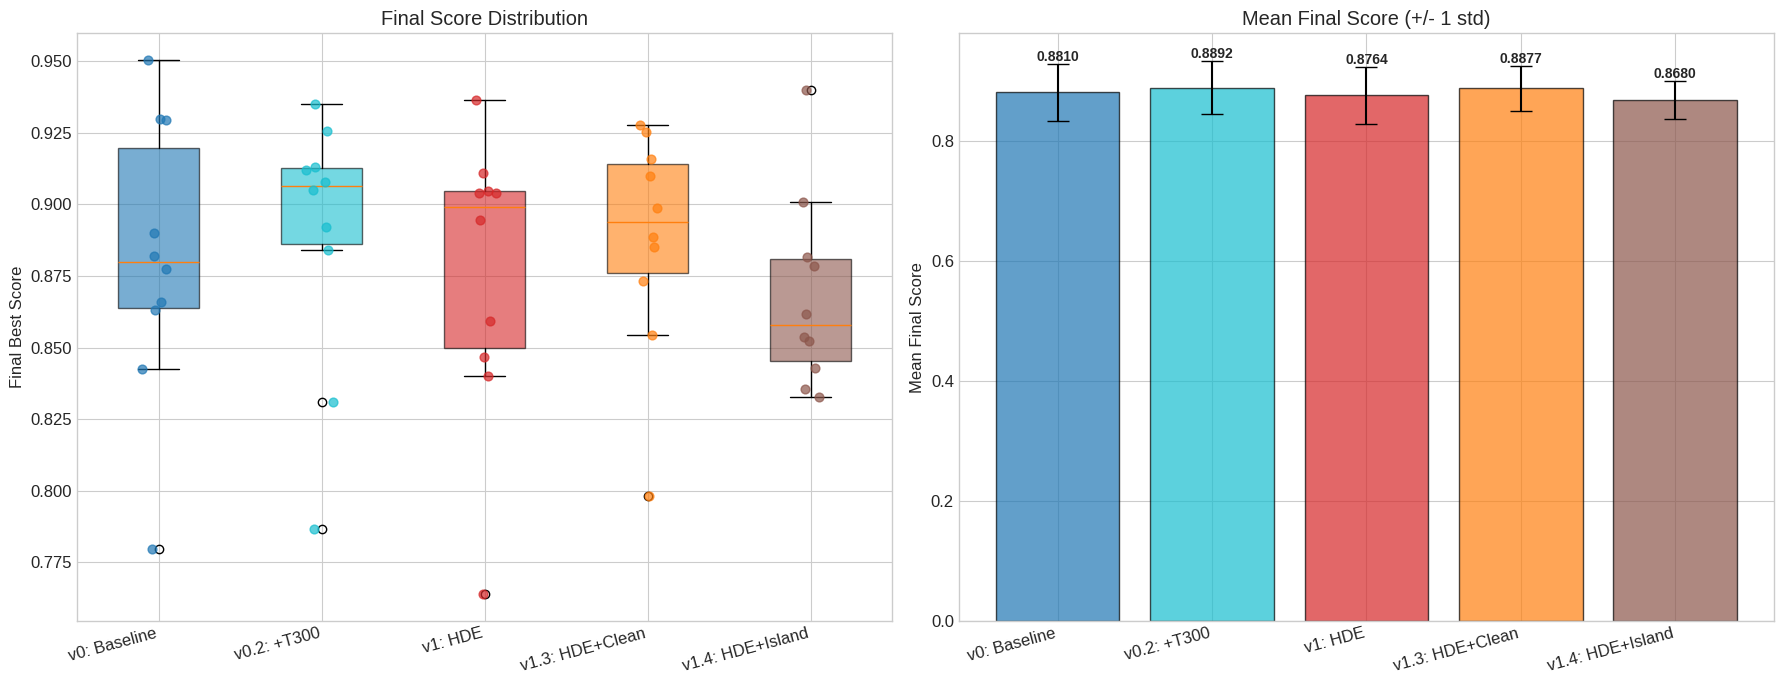


Pairwise Mann-Whitney U tests:
  v0: Baseline vs v0.2: +T300: delta=+0.0082, Cohen d=0.182, p=0.5205 
  v0: Baseline vs v1: HDE: delta=-0.0046, Cohen d=-0.098, p=0.9698 
  v0: Baseline vs v1.3: HDE+Clean: delta=+0.0067, Cohen d=0.158, p=0.7913 
  v0: Baseline vs v1.4: HDE+Island: delta=-0.0130, Cohen d=-0.325, p=0.3075 
  v0.2: +T300 vs v1: HDE: delta=-0.0128, Cohen d=-0.281, p=0.3845 
  v0.2: +T300 vs v1.3: HDE+Clean: delta=-0.0015, Cohen d=-0.038, p=0.7913 
  v0.2: +T300 vs v1.4: HDE+Island: delta=-0.0212, Cohen d=-0.556, p=0.1405 
  v1: HDE vs v1.3: HDE+Clean: delta=+0.0113, Cohen d=0.265, p=0.6775 
  v1: HDE vs v1.4: HDE+Island: delta=-0.0084, Cohen d=-0.207, p=0.3445 
  v1.3: HDE+Clean vs v1.4: HDE+Island: delta=-0.0197, Cohen d=-0.571, p=0.1212 


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Box plot of final scores
final_scores = {}
for name, runs in all_data.items():
    scores = []
    for data in runs.values():
        traj = get_best_trajectory(data)
        if traj:
            scores.append(traj[-1][1])
    final_scores[name] = scores

positions = list(range(len(final_scores)))
bp = axes[0].boxplot(final_scores.values(), positions=positions, widths=0.5, patch_artist=True)
for i, (name, cfg) in enumerate(EXPERIMENTS.items()):
    bp['boxes'][i].set_facecolor(cfg['color'])
    bp['boxes'][i].set_alpha(0.6)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(final_scores.keys(), rotation=15, ha='right')
axes[0].set_ylabel('Final Best Score')
axes[0].set_title('Final Score Distribution')

# Swarm overlay
for i, (name, scores) in enumerate(final_scores.items()):
    jitter = np.random.normal(0, 0.04, len(scores))
    color = EXPERIMENTS[name]['color']
    axes[0].scatter([i + j for j in jitter], scores, color=color, alpha=0.7, s=40, zorder=3)

# Bar chart of means with error bars
names = list(final_scores.keys())
means = [np.mean(s) for s in final_scores.values()]
stds = [np.std(s) for s in final_scores.values()]
colors = [EXPERIMENTS[name]['color'] for name in names]
bars = axes[1].bar(range(len(names)), means, yerr=stds, capsize=8,
                   color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylabel('Mean Final Score')
axes[1].set_title('Mean Final Score (+/- 1 std)')
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
                f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_final_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Pairwise Mann-Whitney U tests
print("\nPairwise Mann-Whitney U tests:")
exp_names = list(final_scores.keys())
for a, b in combinations(exp_names, 2):
    s_a, s_b = final_scores[a], final_scores[b]
    if len(s_a) >= 3 and len(s_b) >= 3:
        _, p = stats.mannwhitneyu(s_a, s_b, alternative='two-sided')
        delta = np.mean(s_b) - np.mean(s_a)
        pooled_std = np.sqrt((np.std(s_a)**2 + np.std(s_b)**2) / 2)
        d = delta / pooled_std if pooled_std > 0 else 0
        sig = "*" if p < 0.05 else ""
        print(f"  {a} vs {b}: delta={delta:+.4f}, Cohen d={d:.3f}, p={p:.4f} {sig}")

## 3. Sample Efficiency (Iterations to Reach Thresholds)

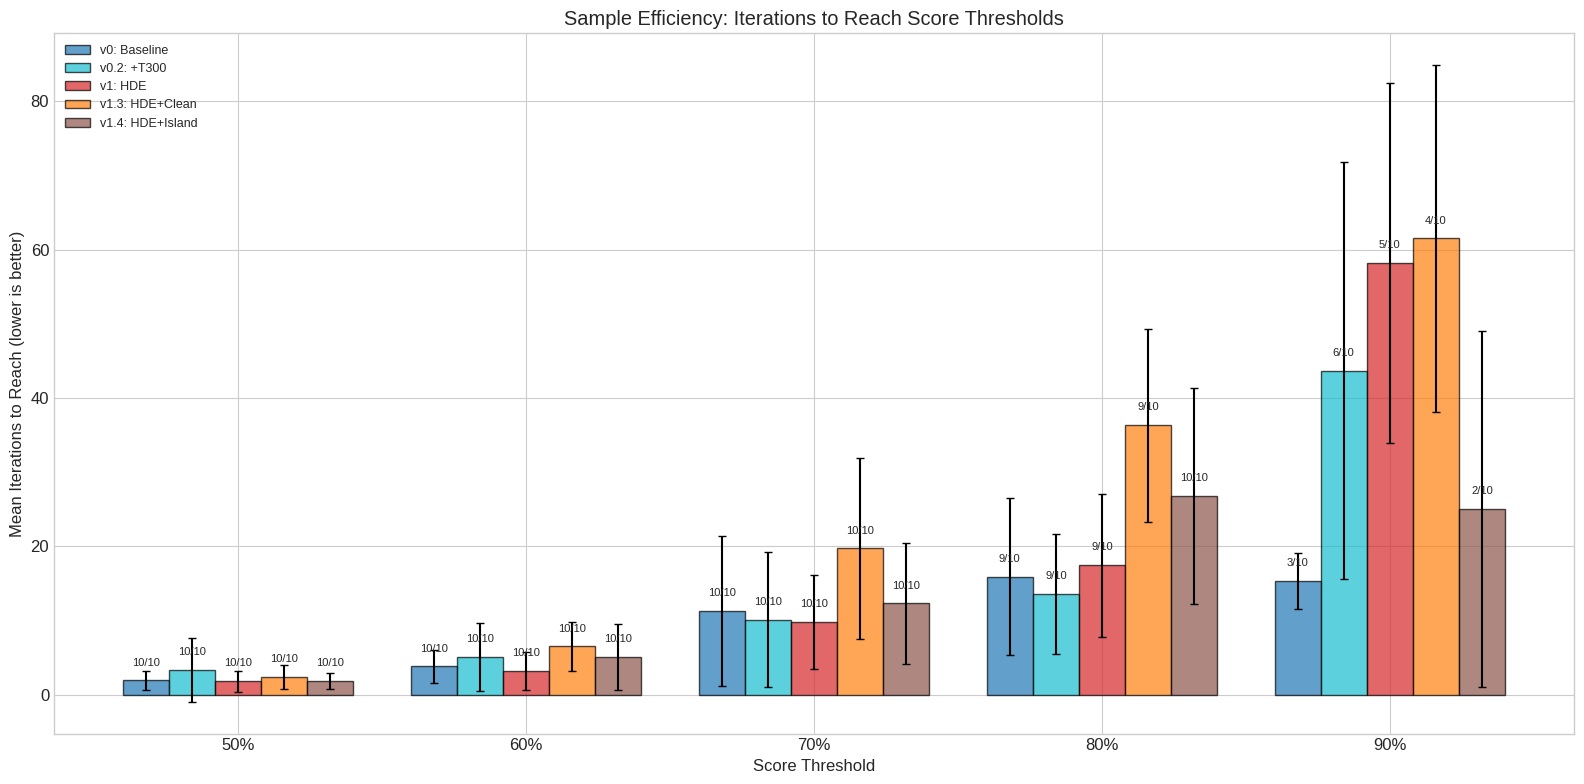

In [16]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

fig, ax = plt.subplots(figsize=(16, 8))

n_exp = len(EXPERIMENTS)
bar_width = 0.8 / n_exp
x = np.arange(len(thresholds))

for idx, (name, cfg) in enumerate(EXPERIMENTS.items()):
    runs = all_data[name]
    iters_to_threshold = {t: [] for t in thresholds}
    
    for data in runs.values():
        traj = get_best_trajectory(data)
        if not traj:
            continue
        for thresh in thresholds:
            reached = None
            for it, score in traj:
                if score >= thresh:
                    reached = it
                    break
            if reached is not None:
                iters_to_threshold[thresh].append(reached)
    
    means = [np.mean(iters_to_threshold[t]) if iters_to_threshold[t] else 100 for t in thresholds]
    stds = [np.std(iters_to_threshold[t]) if len(iters_to_threshold[t]) > 1 else 0 for t in thresholds]
    counts = [len(iters_to_threshold[t]) for t in thresholds]
    
    offset = (idx - n_exp/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, means, bar_width, yerr=stds, capsize=3,
                  label=name, color=cfg['color'], alpha=0.7, edgecolor='black')
    
    for i, (bar, count, total) in enumerate(zip(bars, counts, [len(runs)] * len(thresholds))):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{count}/{total}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'{t:.0%}' for t in thresholds])
ax.set_xlabel('Score Threshold')
ax.set_ylabel('Mean Iterations to Reach (lower is better)')
ax.set_title('Sample Efficiency: Iterations to Reach Score Thresholds')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('comparison_sample_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Error / Waste Rate Comparison

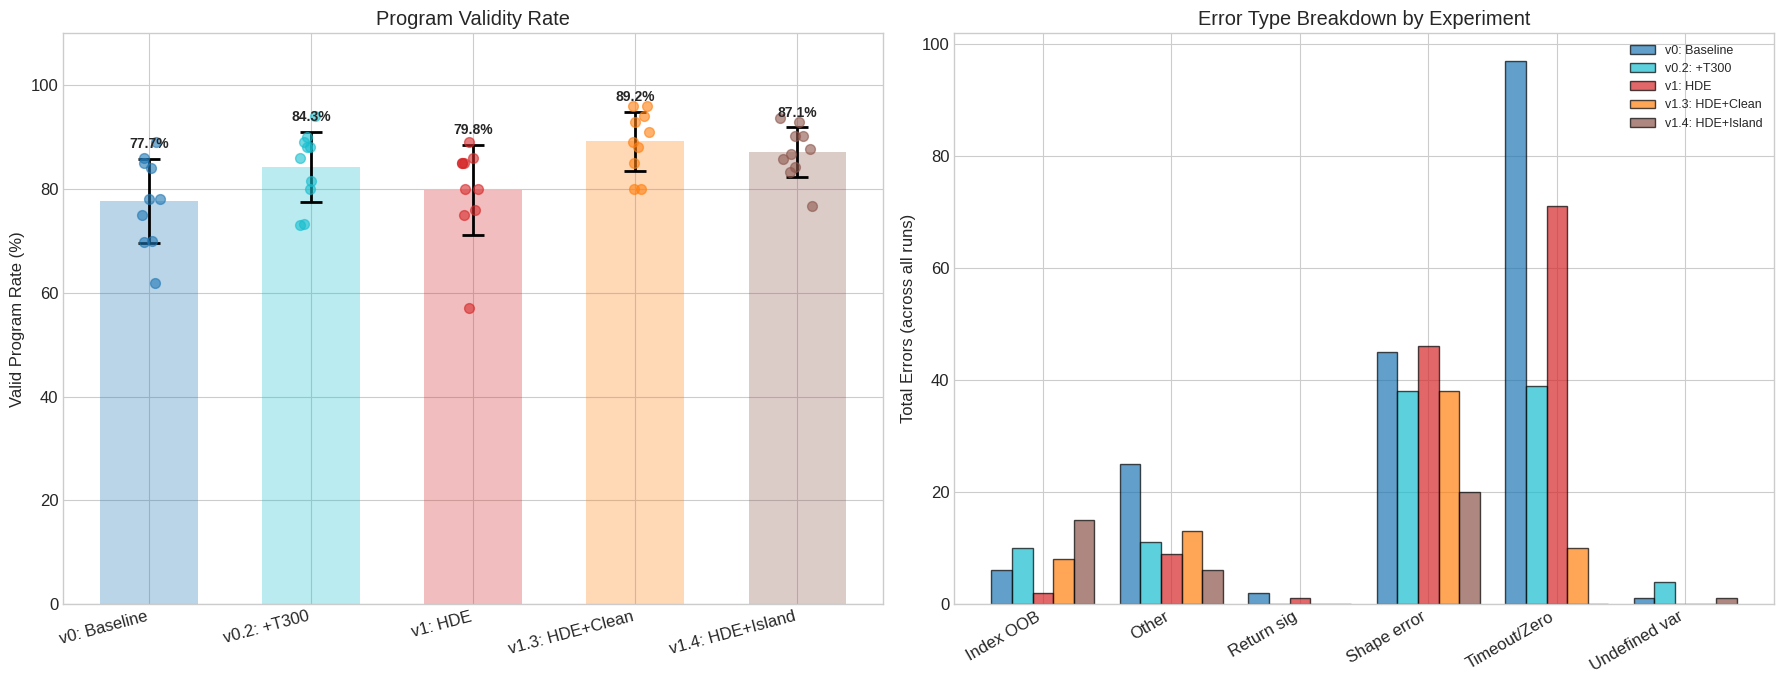

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Valid rate per experiment
for idx, (name, cfg) in enumerate(EXPERIMENTS.items()):
    runs = all_data[name]
    valid_rates = []
    for data in runs.values():
        n_valid = sum(1 for it in data['iterations'] if it.get('combined_score', 0) > 0)
        n_total = len(data['iterations'])
        if n_total > 0:
            valid_rates.append(n_valid / n_total * 100)
    
    jitter = np.random.normal(0, 0.06, len(valid_rates))
    axes[0].scatter([idx + j for j in jitter], valid_rates, color=cfg['color'],
                   alpha=0.6, s=50, zorder=3)
    axes[0].bar(idx, np.mean(valid_rates), color=cfg['color'], alpha=0.3, width=0.6)
    axes[0].errorbar(idx, np.mean(valid_rates), yerr=np.std(valid_rates),
                    color='black', capsize=8, capthick=2, linewidth=2)
    axes[0].text(idx, np.mean(valid_rates) + np.std(valid_rates) + 2,
                f'{np.mean(valid_rates):.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[0].set_xticks(range(len(EXPERIMENTS)))
axes[0].set_xticklabels(EXPERIMENTS.keys(), rotation=15, ha='right')
axes[0].set_ylabel('Valid Program Rate (%)')
axes[0].set_title('Program Validity Rate')
axes[0].set_ylim(0, 110)

# Error type breakdown
all_error_data = {}
for name, runs in all_data.items():
    categories = defaultdict(int)
    for data in runs.values():
        for err in data['errors']:
            err_clean = err.replace('Program execution failed: ', '')
            if 'run_packing' in err_clean:
                categories['Missing run_packing'] += 1
            elif 'index' in err_clean and 'out of bounds' in err_clean:
                categories['Index OOB'] += 1
            elif 'not defined' in err_clean:
                categories['Undefined var'] += 1
            elif 'broadcast' in err_clean or 'shape' in err_clean or 'Invalid shapes' in err_clean:
                categories['Shape error'] += 1
            elif 'not enough values' in err_clean:
                categories['Return sig'] += 1
            elif 'timeout' in err_clean or err_clean.startswith('0.0000'):
                categories['Timeout/Zero'] += 1
            else:
                categories['Other'] += 1
    all_error_data[name] = dict(categories)

# Grouped bar for error categories
all_categories = sorted(set(c for cats in all_error_data.values() for c in cats))
n_exp = len(EXPERIMENTS)
bar_width = 0.8 / n_exp
x = np.arange(len(all_categories))

for idx, (name, cfg) in enumerate(EXPERIMENTS.items()):
    values = [all_error_data[name].get(cat, 0) for cat in all_categories]
    offset = (idx - n_exp/2 + 0.5) * bar_width
    axes[1].bar(x + offset, values, bar_width, label=name,
               color=cfg['color'], alpha=0.7, edgecolor='black')

axes[1].set_xticks(x)
axes[1].set_xticklabels(all_categories, rotation=30, ha='right')
axes[1].set_ylabel('Total Errors (across all runs)')
axes[1].set_title('Error Type Breakdown by Experiment')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparison_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Improvement Rate

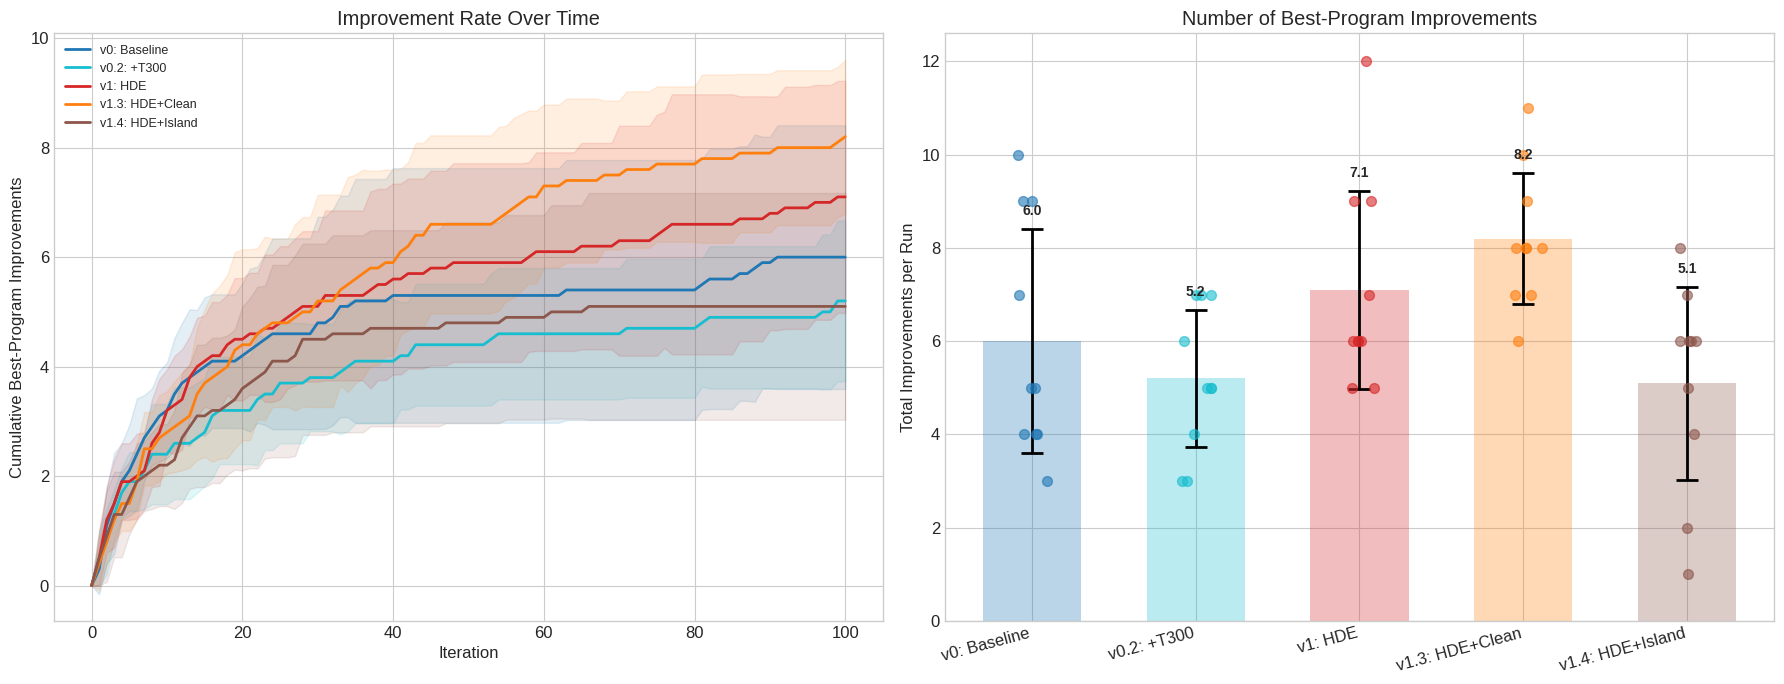

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Cumulative improvements over time
for name, cfg in EXPERIMENTS.items():
    runs = all_data[name]
    all_cum = []
    for data in runs.values():
        events = sorted(data['best_events'])
        if events:
            cum = np.zeros(101)
            for e in events:
                if e <= 100:
                    cum[e:] += 1
            all_cum.append(cum)
    
    if all_cum:
        cum_matrix = np.array(all_cum)
        mean_cum = np.mean(cum_matrix, axis=0)
        std_cum = np.std(cum_matrix, axis=0)
        x = np.arange(101)
        axes[0].plot(x, mean_cum, color=cfg['color'], linewidth=2, label=name)
        axes[0].fill_between(x, mean_cum - std_cum, mean_cum + std_cum,
                            color=cfg['color'], alpha=0.12)

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cumulative Best-Program Improvements')
axes[0].set_title('Improvement Rate Over Time')
axes[0].legend(fontsize=9)

# Total improvements bar chart
for idx, (name, cfg) in enumerate(EXPERIMENTS.items()):
    runs = all_data[name]
    counts = [len(data['best_events']) for data in runs.values()]
    jitter = np.random.normal(0, 0.06, len(counts))
    axes[1].scatter([idx + j for j in jitter], counts, color=cfg['color'],
                   alpha=0.6, s=50, zorder=3)
    axes[1].bar(idx, np.mean(counts), color=cfg['color'], alpha=0.3, width=0.6)
    axes[1].errorbar(idx, np.mean(counts), yerr=np.std(counts),
                    color='black', capsize=8, capthick=2, linewidth=2)
    axes[1].text(idx, np.mean(counts) + np.std(counts) + 0.3,
                f'{np.mean(counts):.1f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_xticks(range(len(EXPERIMENTS)))
axes[1].set_xticklabels(EXPERIMENTS.keys(), rotation=15, ha='right')
axes[1].set_ylabel('Total Improvements per Run')
axes[1].set_title('Number of Best-Program Improvements')

plt.tight_layout()
plt.savefig('comparison_improvements.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary Statistics

In [19]:
print('=' * 80)
print('4-WAY COMPARISON SUMMARY')
print('=' * 80)

summary_data = {}
for name, runs in all_data.items():
    final_scores_list = []
    final_sr = []
    n_improvements = []
    valid_rates_list = []
    n_errors_list = []
    
    for data in runs.values():
        traj = get_best_trajectory(data)
        if traj:
            final_scores_list.append(traj[-1][1])
        
        best_sr = max((it.get('sum_radii', 0) for it in data['iterations']
                       if it.get('validity', 0) > 0), default=0)
        final_sr.append(best_sr)
        n_improvements.append(len(data['best_events']))
        
        n_valid = sum(1 for it in data['iterations'] if it.get('combined_score', 0) > 0)
        n_total = len(data['iterations'])
        valid_rates_list.append(n_valid / max(n_total, 1))
        n_errors_list.append(len(data['errors']))
    
    summary_data[name] = {
        'scores': final_scores_list, 'sr': final_sr,
        'improvements': n_improvements, 'valid': valid_rates_list, 'errors': n_errors_list
    }
    
    print(f'\n{name} (n={len(runs)} runs):')
    print(f'  Final score:     {np.mean(final_scores_list):.4f} +/- {np.std(final_scores_list):.4f}')
    print(f'  Sum radii:       {np.mean(final_sr):.4f} +/- {np.std(final_sr):.4f}  ({np.mean(final_sr)/TARGET*100:.1f}% of target)')
    print(f'  Improvements:    {np.mean(n_improvements):.1f} +/- {np.std(n_improvements):.1f}')
    print(f'  Valid rate:      {np.mean(valid_rates_list)*100:.1f}% +/- {np.std(valid_rates_list)*100:.1f}%')
    print(f'  Total errors:    {np.mean(n_errors_list):.1f} +/- {np.std(n_errors_list):.1f}')

# Pairwise deltas vs baseline
print('\n' + '-' * 80)
print('DELTAS vs BASELINE (v0):')
baseline_scores = summary_data[list(summary_data.keys())[0]]['scores']
for name in list(summary_data.keys())[1:]:
    s = summary_data[name]['scores']
    if s and baseline_scores:
        delta = np.mean(s) - np.mean(baseline_scores)
        pooled_std = np.sqrt((np.std(baseline_scores)**2 + np.std(s)**2) / 2)
        d = delta / pooled_std if pooled_std > 0 else 0
        print(f'  {name}: score delta={delta:+.4f}, Cohen d={d:.3f}')

4-WAY COMPARISON SUMMARY

v0: Baseline (n=10 runs):
  Final score:     0.8810 +/- 0.0468
  Sum radii:       2.3215 +/- 0.1234  (88.1% of target)
  Improvements:    6.0 +/- 2.4
  Valid rate:      77.7% +/- 8.2%
  Total errors:    17.6 +/- 6.1

v0.2: +T300 (n=10 runs):
  Final score:     0.8892 +/- 0.0437
  Sum radii:       2.3431 +/- 0.1151  (88.9% of target)
  Improvements:    5.2 +/- 1.5
  Valid rate:      84.3% +/- 6.7%
  Total errors:    10.2 +/- 3.9

v1: HDE (n=10 runs):
  Final score:     0.8764 +/- 0.0475
  Sum radii:       2.3093 +/- 0.1253  (87.6% of target)
  Improvements:    7.1 +/- 2.1
  Valid rate:      79.8% +/- 8.7%
  Total errors:    12.9 +/- 5.2

v1.3: HDE+Clean (n=10 runs):
  Final score:     0.8877 +/- 0.0371
  Sum radii:       2.3391 +/- 0.0977  (88.8% of target)
  Improvements:    8.2 +/- 1.4
  Valid rate:      89.2% +/- 5.7%
  Total errors:    6.9 +/- 4.6

v1.4: HDE+Island (n=10 runs):
  Final score:     0.8680 +/- 0.0316
  Sum radii:       2.2872 +/- 0.0833  (86.8

## 7. Per-Run Best Program Details

In [20]:
for name, cfg in EXPERIMENTS.items():
    print(f'\n=== {name} ===')
    for i in range(1, cfg['n_runs'] + 1):
        info_path = cfg['dir'] / f'run_{i}' / 'best' / 'best_program_info.json'
        if info_path.exists():
            with open(info_path) as f:
                info = json.load(f)
            sr = info['metrics'].get('sum_radii', 0)
            cs = info['metrics'].get('combined_score', 0)
            et = info['metrics'].get('eval_time', 0)
            print(f'  Run {i:2d}: score={cs:.4f}  sum_radii={sr:.4f}  iter={info.get("iteration","?")}  eval_time={et:.2f}s')
        else:
            print(f'  Run {i:2d}: not found')


=== v0: Baseline ===
  Run  1: score=0.8820  sum_radii=2.3240  iter=88  eval_time=87.16s
  Run  2: score=0.9299  sum_radii=2.4503  iter=12  eval_time=0.21s
  Run  3: score=0.8630  sum_radii=2.2740  iter=86  eval_time=78.11s
  Run  4: score=0.8775  sum_radii=2.3122  iter=23  eval_time=33.29s
  Run  5: score=0.7797  sum_radii=2.0545  iter=33  eval_time=3.32s
  Run  6: not found
  Run  7: score=0.8425  sum_radii=2.2200  iter=89  eval_time=2.95s
  Run  8: score=0.9504  sum_radii=2.5044  iter=21  eval_time=61.92s
  Run  9: not found
  Run 10: score=0.8899  sum_radii=2.3448  iter=91  eval_time=30.30s

=== v0.2: +T300 ===
  Run  1: score=0.9121  sum_radii=2.4034  iter=99  eval_time=12.77s
  Run  2: score=0.7866  sum_radii=2.0727  iter=22  eval_time=154.41s
  Run  3: score=0.9258  sum_radii=2.4394  iter=82  eval_time=144.78s
  Run  4: score=0.9049  sum_radii=2.3844  iter=35  eval_time=7.63s
  Run  5: not found
  Run  6: score=0.9349  sum_radii=2.4634  iter=99  eval_time=0.73s
  Run  7: score=